# 2025-10-31: Further Analysis of Plasma Cell States using 2 gene sets from publications
#### By [Aishwarya Chander](aishwarya.chander@alleninstitute.org), High Resolution Translational Immunology, Allen Institute for Immunology

**Main aim**: We want to know what the states are within each cluster of the Plasma Cells using gene sets collected from publications.
1. Publication 1 - https://pubmed.ncbi.nlm.nih.gov/20574050/
2. Publication 2 - https://www.nature.com/articles/s41467-022-33944-z

## 1. Imports

In [1]:
import scanpy as sc
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy import stats
import decoupler as dc
import gseapy as gp

sc.settings.n_jobs = 30
sc.settings.verbosity = 0

plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (5, 5)
sc.settings.set_figure_params(
    dpi=80,
    facecolor='white',
    frameon=False,
    fontsize=10, 
    figsize=(4,4), 
    format='png'
)

## 2. Grab preTx plasma cells

In [2]:
adata = sc.read_h5ad('../../../data/rna/plasma-subsets/pretx-plasma-paga.h5ad')

In [3]:
cluster_dict = {
    '0': 'NDMM 0',
    '1': 'NDMM 1',
    '2': 'NDMM 2',
    '3': 'NDMM 3',
    '4': 'NDMM 4',
    '5': 'NDMM 5',
    '6': 'NDMM 6',
    '7': 'NDMM 7',
    '8': 'NDMM 8',
    '9': 'NDMM 9',
    '10': 'NDMM 10',
    '11': 'NDMM 11'
}

adata.obs['plasma_labels_l3'] = adata.obs['leiden'].map(lambda x: cluster_dict.get(x, x)).astype('category')

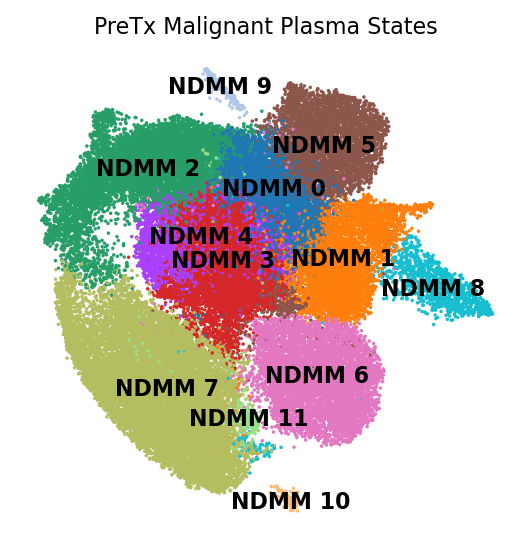

In [4]:
sc.pl.umap(
    adata,
    color='plasma_labels_l3',
    size=10,
    legend_loc='on data',
    legend_fontsize=10,
    title='PreTx Malignant Plasma States'
)

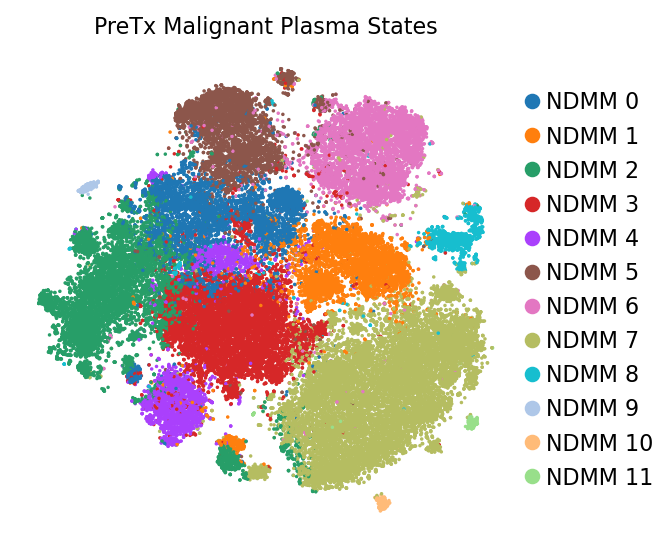

In [5]:
sc.pl.tsne(
    adata,
    color='plasma_labels_l3',
    size=10,
    legend_fontsize=10,
    title='PreTx Malignant Plasma States'
)

## 3. Gene expression signature scoring

### 3.1. Gene expression profiling for molecular classification of multiple myeloma in newly diagnosed patients
Signature Source - [Broyl et al. 2010](https://pubmed.ncbi.nlm.nih.gov/20574050/), [Supplementary Data Table, Sheet 5](https://ash.silverchair-cdn.com/ash/content_public/journal/blood/116/14/10.1182_blood-2009-12-261032/4/zh2543-sup-document1.xls?Expires=1773988782&Signature=VB4DIaX3AoesFzFiXUML0uTSSLpGWoJUnNAOtLeM4P6IWUIxCraCwzMpAADr-XNTdsgtWSt~d6-7xMNXtgr1BCSj8ic8YUMRLhYDGBf8Wvs5SvKrSLxzhKC5JPdqY~dPLhI9B8p9olxsPAW4734u9q6ONJpMbbzgzT5HUpiG15bli8yzWdyR3wAxOsZtN1BqQSGk72bZh22X8SW66TgnDuOIeV-Z2gLgJaAPuxfzgBev4FH79YWfpeexEp~gRoZFAyVJpmgqaekaY~HDPorfv9-zpy53vveTS-ou4ua49ExZjp6gsDdx3Y4-C3EwNlf1o58v2ey5mC~IGTwu59qleg__&Key-Pair-Id=APKAIE5G5CRDK6RD3PGA)

> Note that several genes from this study are inconsistent with HGNC standards as of 2025 and have been updated to match current closest gene names.

In [6]:
broyl_signatures = {
    'CD1_down': ['CD9', 'SERPINI1', 'AREG', 'PERP', 'GOLGA8DP', 'MLLT11', 'NOTCH2NL', 'HOMER3', 'SIK1'],
    'CD1_up': ['SHISA2', 'MACROD2', 'INHBE', 'LPAR6', 'FCER2', 'ASS1', 'KCNMB2', 'ETV1', 'BCAT1', 'MKX', 'CTH', 'TMC6', 'RRAS2', 'BANK1', 'SLC7A11', 'CCND1', 'LRATD2', 'NID2', 'CD99', 'CERS6', 'FERMT2', 'TM6SF1', 'BATF3', 'WARS1', 'CLEC2D', 'G0S2', 'ALCAM', 'CHAC1', 'RFTN1', 'NET1', 'IRAK2', 'MDK', 'STS', 'METRNL', 'SNX9', 'LY6E', 'CD19', 'VLDLR', 'NACC1'],
    'CD2_down': ['MICOS13', 'CCND2', 'CSF2RB', 'KCNS3', 'IL6R', 'CD44', 'UCHL1', 'LINC01508', 'GBA3', 'GPRC5D', 'EFEMP1', 'HIST1H1C', 'FABP5', 'FABP5P2', 'FABP5P7', 'SERPINI1', 'PRR15', 'CCR10', 'CCRL2', 'AREG', 'ARL4C', 'HIST2H2AA3', 'HIST2H2AA4', 'DUSP4', 'SULF2', 'TMEM45A', 'RARRES3', 'HIST1H2AC', 'DDIT4', 'PLEK', 'CALHM6', 'RRAGD', 'GOLGA8DP', 'SOX4', 'FGL2', 'ITGB5', 'ELOVL4'],
    'CD2_up': ['CCND1', 'MS4A1', 'KCNMB2', 'SLC8A1', 'VPREB3', 'PHLDA1', 'FGD4', 'ANK3', 'FCRL3', 'SORT1', 'FCRLB', 'LAPTM5', 'CD27', 'CD79A', 'MARCKS', 'NLGN4X', 'BANK1', 'RGS13', 'METRNL', 'RPS6KC1', 'RNF144B', 'PLD4', 'FCRL2', 'ADAM28', 'RAPH1', 'NT5DC2', 'FBP1', 'NFIB', 'BTG1', 'TXLNG', 'CTHRC1', 'PLXNB2', 'DAAM1', 'ADGRL2'],
    'CTA_down': ['HDLBP', 'EIF5B', 'CAST', 'NUCB2', 'TAX1BP1', 'MALAT1', 'HSP90AA1', 'EIF3A', 'TTC3', 'ZBTB38', 'LAMC1', 'SEC63', 'SON', 'JAK1', 'TOP1', 'EPRS1', 'SMC4', 'IQGAP1', 'ALCAM', 'ARID5B', 'IFI16', 'PRRC2C', 'MTDH', 'C4A', 'C4B', 'HSP90B1', 'AHNAK', 'BCLAF1', 'TOP2B', 'RAPGEF2', 'ECPAS', 'SETBP1', 'SH3KBP1', 'CARMIL1', 'EZR', 'FAM13A', 'USP16', 'HIPK2', 'CD2AP', 'ANKRD12', 'NOLC1', 'KPNB1', 'HNRNPU'],
    'CTA_up': ['HIST1H2BG', 'GINS1', 'DUT', 'MTHFD2L', 'HBB', 'HBD', 'PHF19', 'MEST', 'CDK1', 'MAGEA3', 'BIRC5', 'CTNNB1', 'TGS1', 'TMEM17', 'TMX2', 'MAGEA6', 'PXMP2', 'CDC42', 'ST3GAL6', 'FCRLA', 'PCLAF', 'TMEM107', 'TDO2', 'PRPS2', 'PBK', 'ITM2A', 'MAGEA12', 'RRM2', 'TM2D3', 'ACP5', 'ISG15', 'TM7SF3', 'CDKN2C', 'PAGE1', 'PTTG1', 'SAPCD1', 'OCIAD1', 'PKIG', 'SVOP', 'GAGE12F', 'GAGE12G', 'GAGE12I', 'GAGE12J', 'GAGE7', 'ID2', 'ID2B', 'E2F2', 'TSPAN6'],
    'HY_down': ['CCND2', 'DHRS9', 'S100A4', 'CD99', 'MYADM', 'TIMP1', 'COCH', 'SELL', 'BEX3', 'TUBA1A', 'SLC8A1', 'ARL4C', 'CTHRC1', 'PMAIP1', 'CD52', 'ETV1', 'EZR', 'PHLDA1', 'GLIPR1', 'FHL1', 'AGA', 'NIBAN1', 'MAL', 'CD9', 'IGFBP7', 'MS4A1', 'CTSH', 'TUBB2A', 'FGFR3', 'FCRLA', 'OSBPL1A', 'PITPNC1', 'GGH', 'RND3', 'CDKN1C', 'DOCK11', 'KLF6', 'CHPT1', 'AP1S2', 'CD81', 'KLF4', 'DEK'],
    'HY_up': ['GBA3', 'MICOS13', 'IFIT1', 'TNFSF10', 'NCAM1', 'KIT', 'MAGEC1', 'FAM13A', 'CCRL2', 'EFEMP1', 'TRAT1', 'CCDC85A', 'WNT5A', 'FRZB', 'SULF2', 'RSAD2', 'DKK1', 'MAGI2', 'RELN', 'IFIT3', 'CCR2', 'EPHB1', 'RPL37', 'COL4A5', 'COL4A6', 'IGK', 'IGKC', 'IGKV3-20', 'IGKV3D-11', 'IGKV3D-15', 'XAF1', 'SLC2A5', 'MX1', 'KANK1', 'PFKFB2', 'GNG11', 'DUSP2', 'IFI27', 'ATP10B', 'MYC', 'MEIS2', 'CCND1', 'SLC16A14', 'NOL4', 'GOLGA8DP', 'OSBPL10'],
    'MF_down': ['DKK1', 'CMPK2', 'BASP1', 'FRZB', 'IGKC', 'IGKV1-5', 'TNFSF10', 'CTHRC1', 'RSAD2', 'STAP1', 'CCND1', 'IGKV4-1', 'HBB', 'HBD', 'ADM', 'NCAM1', 'ATP10B', 'CPVL', 'NLGN4X', 'CCDC85A', 'HOMER1', 'JCHAIN', 'IGH', 'IGHA1', 'IGHA2', 'IGHV3OR16-13', 'IFI27', 'IGL', 'IL5RA', 'CTSC', 'IFI6', 'AMPD1', 'FAM13A', 'GOLGA8DP', 'TMEM45A', 'PIP5K1B', 'TRAT1', 'KCNMB2', 'VCAM1', 'RELN', 'HLA-DPA1', 'MYEOV', 'SYNGR1'],
    'MF_up': ['CCND2', 'RND3', 'AHNAK', 'DOCK11', 'ARL4C', 'RASGRP1', 'NUAK1', 'EHD3', 'PRR15', 'SFN', 'GULP1', 'CX3CR1', 'DPYSL2', 'CD52', 'PLA2G16', 'PITPNC1', 'ITGB7', 'BIRC3', 'BAMBI', 'ARHGAP6', 'ARHGEF3', 'CST6', 'MIR155HG', 'CRIP1', 'RAPH1', 'CDKN1C', 'ABLIM1', 'INAVA', 'TFAP2C', 'CD109', 'SLA', 'GPM6B', 'PHACTR3', 'CLEC7A', 'MTSS1', 'IL6R', 'RRAS2', 'ETS1', 'SPN'],
    'MS_down': ['CCND1', 'FRZB', 'MS4A1', 'LAPTM5', 'MAGEC1', 'DUSP2', 'SYK', 'SLC35F2', 'RGS1', 'RGS13', 'CD79A', 'NOL4', 'KCNMB2', 'TIAM1', 'ADM', 'SNHG7', 'RPL37', 'IL10RA', 'TFEB', 'DPP7', 'GPX1', 'EPSTI1', 'STARD10', 'SPARC', 'HEY1', 'KISS1R', 'PTPRJ', 'COBLL1', 'FGL2', 'CYRIB', 'OVOS2', 'CCRL2', 'PDLIM1', 'METRNL', 'SYNGR3', 'ESRRA', 'SH3BP5', 'SPEF2'],
    'MS_up': ['FGFR3', 'NSD2', 'CCND2', 'DSG2', 'UCHL1', 'SERPINE2', 'BEX3', 'LINC01508', 'KLF4', 'SELL', 'CLGN', 'LINC00892', 'PTP4A3', 'APP', 'TIMP1', 'AZGP1', 'PPIC', 'CTHRC1', 'GNB4', 'IGFBP7', 'PLOD2', 'CST3', 'MAGED4', 'MAGED4B', 'MAL', 'BACE2', 'TMEM47', 'SGCB', 'EPDR1', 'MYADM', 'SERPINI1', 'ETV1', 'CD99', 'S100A4', 'TSPAN7', 'TMEM176B', 'ANG', 'ROBO1', 'TMEM176A', 'GPRC5D', 'NIBAN1', 'FCRLA', 'SATB1', 'MPPED2'],
    'M_down': ['PTP4A1', 'SLC35F2', 'ST3GAL6', 'CPNE5', 'PRMT1', 'HSP90AB1', 'DUSP5', 'SMAD7', 'TMEM123', 'TMEM254', 'PDE4B', 'BMP6', 'INPP1', 'CCDC47', 'SLC44A1', 'BIRC2', 'STT3A', 'GLCCI1', 'IRF4', 'CFAP68', 'CFL2', 'FBXO3', 'ALG9', 'ACAT1', 'TSPAN3', 'CREB3', 'HSPA8', 'NT5C1B', 'RDH14', 'PHTF1', 'DNAJC10', 'TMEM126A', 'TPD52', 'TMX3', 'SLC25A6', 'PSMA1', 'BCAP31', 'RANBP6', 'ITM2B', 'SMARCC1'],
    'M_up': ['DEFA1', 'DEFA3', 'AIF1', 'HLA-DPB1', 'DEFA4', 'S100A8', 'LYZ', 'CA1', 'CD163', 'PPBP', 'HLA-DPA1', 'CSTA', 'MS4A6A', 'HBA1', 'HBA2', 'HBG1', 'HBG2', 'MNDA', 'MS4A7', 'FCER1G', 'FGL2', 'TYROBP', 'S100A12', 'VCAM1', 'MPO', 'HLA-DQA1', 'FCN1', 'CTSG', 'TCF7L2', 'ANXA1', 'YJEFN3', 'S100A9', 'PTPRC', 'ITGB2', 'TGFBI', 'PEAR1', 'KCTD12', 'LTF', 'GGTA1', 'CD14', 'HBB', 'PF4', 'CXCL12'],
    'NF_down': ['CCR2', 'ANKRD46', 'MAT2A', 'SACM1L', 'PPM1B', 'KANK1', 'G3BP1', 'SMC4', 'COPB2', 'LBR', 'SRP54', 'ZRANB2', 'CDK1', 'HMMR', 'ATP6V1D', 'CD200', 'GTF2A1', 'MEF2C', 'SRSF1', 'CHST15', 'ARHGEF3', 'SLC16A14', 'TOP1', 'RNF34', 'RRM2', 'DIPK1A', 'GLS', 'PTPRC', 'EFR3A', 'RASA1', 'SON', 'HSPA1A', 'HSPA1B', 'GINS1', 'AP3M1', 'NSL1', 'BET1', 'PLA2G4A', 'NSF', 'BUB1B', 'MUT', 'POLR2B', 'MIDEAS', 'ATP10B', 'LUC7L3', 'GANC', 'DTL', 'XPO1', 'RBM5'],
    'NF_up': ['CDC42', 'TNFAIP3', 'COBLL1', 'BCL10', 'ATXN1', 'EZR', 'ARMH2', 'EPC1', 'TAGAP', 'MAFF', 'ILRUN', 'CXCL8', 'TUBB2A', 'BTG1', 'GADD45B', 'MBNL1', 'UBALD1', 'KLF9', 'NFKBIE', 'NDUFA10', 'PCIF1', 'CCL3', 'CCL3L1', 'CCL3L3', 'CNR1', 'SPTBN1', 'PTP4A1', 'RAB11FIP1', 'KLF6', 'EDNRB', 'SUN1', 'RIPK2', 'EHD4', 'KLF11', 'MIR155HG', 'LMNA'],
    'PRL3_down': ['LAPTM5', 'CD44', 'TMSB4X', 'TMSB4XP8', 'DUSP6', 'PDLIM1', 'SMAP2', 'CAT', 'PRNP'],
    'PRL3_up': ['CCND2', 'PTP4A3', 'PTPRZ1', 'SOCS3', 'RNF130', 'DEPP1', 'SMYD3', 'ARFGEF3', 'PPARGC1A', 'WSCD1', 'MPPE1', 'FBXO32', 'MUC1', 'IGHG1', 'ETV5', 'CAVIN4'],
    'PR_down': ['GLUL', 'CD27', 'CXCR4', 'FCRLA', 'HLA-DOB', 'CD74', 'TLE1', 'FCGR2B', 'HLA-DPA1', 'KLF6', 'FGD2', 'P2RX5', 'TAPBPL', 'FCRL5', 'MARCKS', 'HLA-DPB1', 'COTL1', 'PLEK', 'TMEM156', 'RNGTT', 'TAGAP', 'OTUD1', 'BLNK', 'KLF3', 'NPC2', 'KLHL5', 'SMAP2', 'LAMP3', 'CHPT1', 'PDE4B', 'CPNE5', 'CD40', 'HLA-DRB1', 'LY96', 'LMNA', 'MEI1', 'ALCAM', 'GABARAPL1', 'GABARAPL3', 'PNOC', 'ITM2C', 'PECAM1', 'CYSLTR1'],
    'PR_up': ['RUNX2', 'SCN3A', 'CDK1', 'GINS1', 'GAGE12F', 'GAGE12G', 'GAGE12I', 'GAGE12J', 'GAGE7', 'TOP2A', 'ATP10B', 'MAGEA3', 'DTL', 'BUB1B', 'CCNB1', 'KIF11', 'SLC16A14', 'MACROD2', 'MYLK', 'MAGEA6', 'RRM2', 'FAM72A', 'FAM72B', 'FAM72D', 'CCSAP', 'AURKA', 'SYT1', 'HMMR', 'PBK', 'GLDC', 'CENPK', 'GABRB2', 'CENPA', 'CDKN2C', 'BIRC5', 'PHF19', 'SMC4', 'DUT', 'NIBAN1', 'NSMCE1', 'PCLAF', 'GAGE1', 'GAGE4', 'GAGE5', 'GAGE6', 'DCK', 'NEK2', 'STIL', 'ATAD2', 'HOMER1', 'RACGAP1', 'WEE1', 'GCAT'],
}

In [7]:
# Filter signatures and drop any with 1 or fewer genes
filtered_sigs = {
    name: [g for g in genes if g in adata.var_names] 
    for name, genes in broyl_signatures.items()
}

# Remove signatures with 1 or fewer genes
filtered_sigs = {name: genes for name, genes in filtered_sigs.items() if len(genes) > 1}

# Print summary
for name, genes in filtered_sigs.items():
    original_count = len(broyl_signatures[name])
    found_count = len(genes)
    print(f'{name}: {found_count}/{original_count} genes found')

CD1_down: 8/9 genes found
CD1_up: 37/39 genes found
CD2_down: 32/37 genes found
CD2_up: 33/34 genes found
CTA_down: 42/43 genes found
CTA_up: 43/48 genes found
HY_down: 41/42 genes found
HY_up: 37/46 genes found
MF_down: 32/43 genes found
MF_up: 39/39 genes found
MS_down: 34/38 genes found
MS_up: 42/44 genes found
M_down: 39/40 genes found
M_up: 37/43 genes found
NF_down: 47/49 genes found
NF_up: 34/36 genes found
PRL3_down: 8/9 genes found
PRL3_up: 15/16 genes found
PR_down: 42/43 genes found
PR_up: 47/53 genes found


In [8]:
for cluster in ['CD1', 'CD2', 'CTA', 'HY', 'M', 'MF', 'MS', 'NF', 'PR', 'PRL3']:
    sc.tl.score_genes(adata, filtered_sigs[f'{cluster}_up'], 
                      score_name=f'{cluster}_up')

### 3.2. Single cell characterization of myeloma and its precursor conditions reveals transcriptional signatures of early tumorigenesis
Signature Source - [Boiarsky et al. 2022](https://www.nature.com/articles/s41467-022-33944-z), [Supplementary Data 8
](https://static-content.springer.com/esm/art%3A10.1038%2Fs41467-022-33944-z/MediaObjects/41467_2022_33944_MOESM11_ESM.xlsx)

In [9]:
# Myeloma gene signatures
boiarsky_signatures = {
    'W1_unknown': ['JUNB', 'ZFP36', 'NFKBIA', 'IER2'],
    'W2_MM1': ['MTDH', 'HLA-A', 'IFI27', 'SNHG25'],
    'W3_t11_14': ['CCND1', 'TSC22D3', 'RP5-887A10.1', 'RGS13'],
    'W4_HLA_class_II': ['HLA-DRA', 'HLA-DRB1', 'HLA-DPA1', 'HLA-DPB1'],
    'W5_histones': ['HIST1H1C', 'HIST1H2AC', 'HIST1H2BC', 'KIAA0556'],
    'W6_unknown': ['DUSP4', 'GADD45A', 'BTG2', 'LAMP5'],
    'W7_MM4': ['IFI6', 'PTP4A3', 'HLA-A', 'LAG3'],
    'W8_t14_20': ['ITGB7', 'AC233755.2', 'SPP1', 'CCND2'],
    'W9_extracellular_signaling': ['LGALS1', 'VIM', 'ACTB', 'S100A6'],
    'W10_RPL36A': ['RPL36A', 'NBEAL1', 'IFITM1', 'LAMP5'],
    'W11_proliferation': ['HIST1H4C', 'STMN1', 'TUBA1B', 'HMGB2'],
    'W12_monocytic_contamination': ['SAT1', 'S100A9', 'S100A8', 'CRIP1'],
    'W13_FOS': ['FOS', 'RPPH1', 'ID1', 'CDKL3'],
    'W14_unknown': ['KLF6', 'TSC22D3', 'ANKRD28', 'KLF2'],
    'W15_SMM8': ['AREG', 'KLF4', 'NEAT1', 'CTA-292E10.6'],
    'W16_normal_plasma': ['CD27', 'CD79A', 'TXNIP', 'JSRP1'],
    'W17_MM5': ['EIF3L', 'MYC', 'RPL36A', 'JUNB'],
    'W18_JUN': ['JUN', 'FOSB', 'EGR1', 'IER2'],
    'W19_SMM7': ['CST3', 'ITM2C', 'MTDH', 'TIMP1'],
    'W20_protein_synthesis': ['HNRNPH1', 'PIM2', 'C16orf54', 'PHKG1'],
    'W21_HSPA5': ['HSPA5', 'CST6', 'EPCAM', 'HYOU1'],
    'W22_TMSB4X': ['TMSB4X', 'PMAIP1', 'LAPTM5', 'FNBP1'],
    'W23_MM3': ['FRZB', 'CCL3', 'CCL4', 'DKK1'],
    'W24_interferon_inducible': ['ISG15', 'MX1', 'TNFSF10', 'LY6E'],
    'W25_UBC': ['UBC', 'C1GALT1C1', 'SLC3A2', 'LMF1'],
    'W26_unknown': ['HLA-A', 'ITM2C', 'PRR15', 'ACTB'],
    'W27_nuclear_genes_opposite': ['NEAT1', 'DDX17', 'ANKRD12', 'FOXO3'],
    'W28_CXCR4': ['CXCR4', 'RGS1', 'RGS2', 'ICA1L'],
}

In [10]:
# Filter signatures and drop any with 1 or fewer genes
filtered_sigs = {
    name: [g for g in genes if g in adata.var_names] 
    for name, genes in boiarsky_signatures.items()
}

# Remove signatures with 1 or fewer genes
filtered_sigs = {name: genes for name, genes in filtered_sigs.items() if len(genes) > 1}

# Print summary
for name, genes in filtered_sigs.items():
    original_count = len(boiarsky_signatures[name])
    found_count = len(genes)
    print(f'{name}: {found_count}/{original_count} genes found')

W1_unknown: 4/4 genes found
W2_MM1: 4/4 genes found
W3_t11_14: 3/4 genes found
W4_HLA_class_II: 4/4 genes found
W5_histones: 4/4 genes found
W6_unknown: 4/4 genes found
W7_MM4: 4/4 genes found
W8_t14_20: 4/4 genes found
W9_extracellular_signaling: 4/4 genes found
W10_RPL36A: 3/4 genes found
W11_proliferation: 4/4 genes found
W12_monocytic_contamination: 4/4 genes found
W13_FOS: 3/4 genes found
W14_unknown: 4/4 genes found
W15_SMM8: 3/4 genes found
W16_normal_plasma: 4/4 genes found
W17_MM5: 3/4 genes found
W18_JUN: 4/4 genes found
W19_SMM7: 4/4 genes found
W20_protein_synthesis: 4/4 genes found
W21_HSPA5: 4/4 genes found
W22_TMSB4X: 4/4 genes found
W23_MM3: 4/4 genes found
W24_interferon_inducible: 4/4 genes found
W25_UBC: 4/4 genes found
W26_unknown: 4/4 genes found
W27_nuclear_genes_opposite: 4/4 genes found
W28_CXCR4: 4/4 genes found


In [11]:
for cluster in list(filtered_sigs.keys()):
    sc.tl.score_genes(adata, filtered_sigs[f'{cluster}'], 
                      score_name=f'{cluster}')

### 3.3. APOBEC Signature Analysis
Source - In house expertise
> Calculate cluster-based APOBEC3A/3B signature scores using z-normalized average expression across cell clusters.

In [12]:
def calculate_apobec_score(adata, cluster_col='plasma_labels_l3'):
    '''Calculate APOBEC signature scores for single cell data'''

    apobec_genes = ['APOBEC3A', 'APOBEC3B']

    # Find available genes
    available_genes = [gene for gene in apobec_genes if gene in adata.var_names]

    if not available_genes:
        raise ValueError('No APOBEC genes found in dataset')

    # Calculate cluster averages
    cluster_avg = pd.DataFrame(index=adata.obs[cluster_col].unique())

    for gene in available_genes:
        gene_exp = (
            adata[:, gene].X.toarray().flatten()
            if hasattr(adata[:, gene].X, 'toarray')
            else adata[:, gene].X.flatten()
        )
        temp_df = pd.DataFrame(
            {'cluster': adata.obs[cluster_col].values, 'expression': gene_exp}
        )
        cluster_avg[gene] = temp_df.groupby('cluster')['expression'].mean()

    # Z-score normalize across clusters
    cluster_z = cluster_avg.apply(stats.zscore, axis=0)

    # Calculate signature scores
    cluster_z['APOBEC_score_max'] = cluster_z[available_genes].max(axis=1)
    cluster_z['APOBEC_score_mean'] = cluster_z[available_genes].mean(axis=1)

    # Map scores back to cells and ensure float type
    adata.obs['APOBEC_score_max'] = (
        adata.obs[cluster_col].map(cluster_z['APOBEC_score_max']).astype(float)
    )
    adata.obs['APOBEC_score_mean'] = (
        adata.obs[cluster_col].map(cluster_z['APOBEC_score_mean']).astype(float)
    )

    return cluster_z

In [13]:
apobec_scores = calculate_apobec_score(adata)

/tmp/ipykernel_22840/2489691165.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_avg[gene] = temp_df.groupby('cluster')['expression'].mean()
/tmp/ipykernel_22840/2489691165.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_avg[gene] = temp_df.groupby('cluster')['expression'].mean()


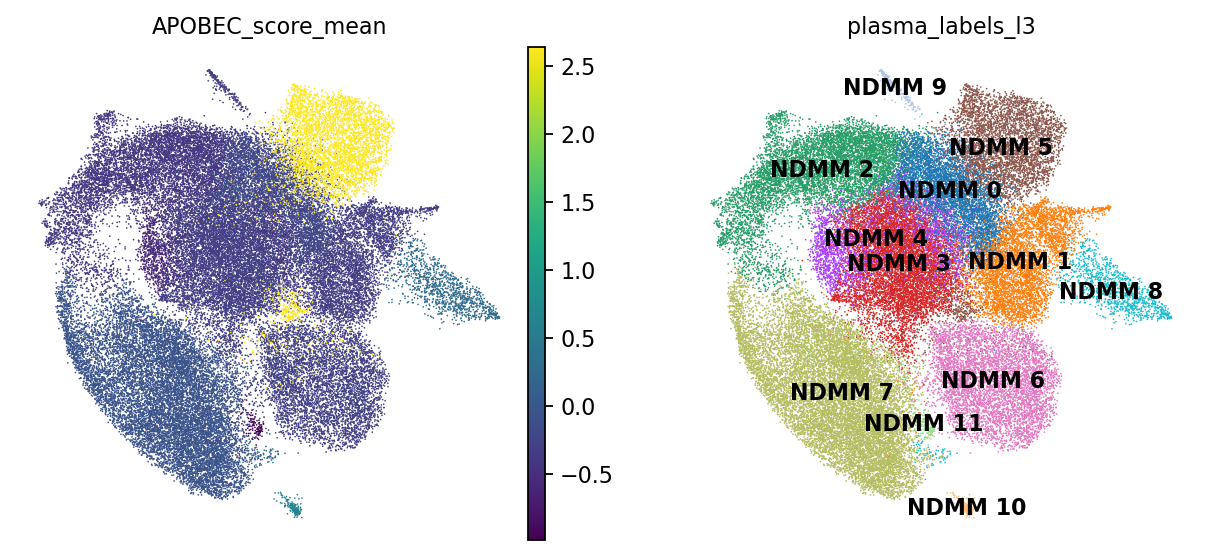

In [14]:
sc.pl.umap(adata, color = ['APOBEC_score_mean', 'plasma_labels_l3'], legend_loc='on data')

### 3.4. Interferon Response Analysis
Source - In house expertise
>Analyzing interferon alpha and gamma responses in plasma cell states using AUCell scoring with MSigDB Hallmark pathways.

In [15]:
gs = gp.get_library(name='MSigDB_Hallmark_2020', organism='Human')
net = pd.DataFrame(
    [(pathway, gene) for pathway, genes in gs.items() for gene in genes],
    columns=['source', 'target'],
)

2026-03-01 21:58:03 | [INFO] Downloading and generating Enrichr library gene sets...


In [16]:
dc.mt.aucell(adata, net, tmin=3)

adata.obs['Interferon_Alpha_Response'] = adata.obsm['score_aucell'][
    'Interferon Alpha Response'
]
adata.obs['Interferon_Gamma_Response'] = adata.obsm['score_aucell'][
    'Interferon Gamma Response'
]

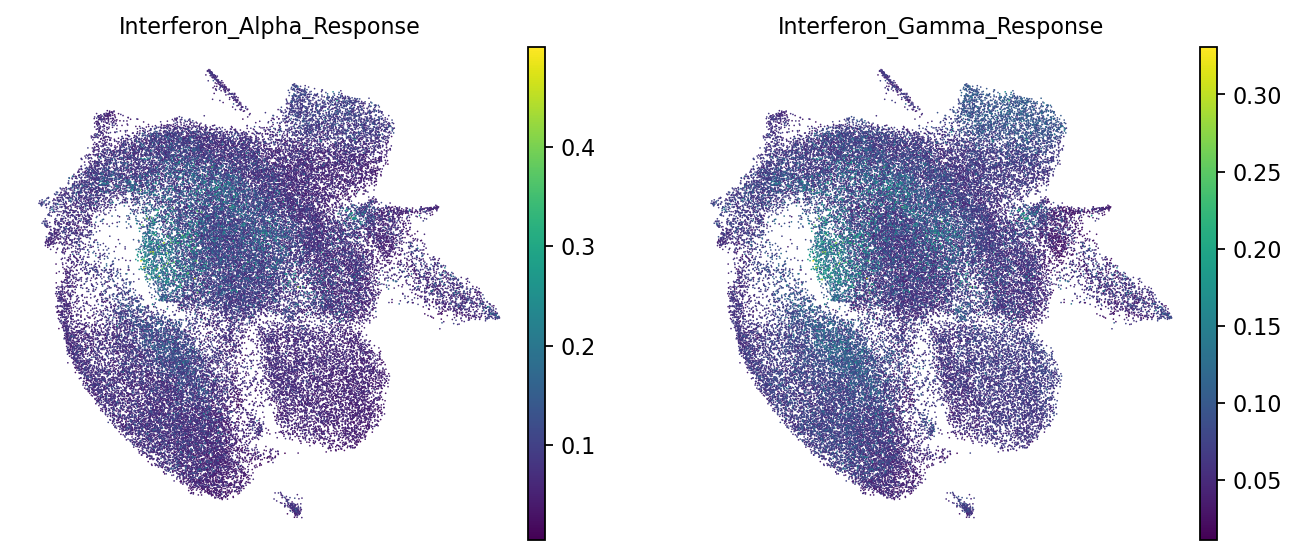

In [17]:
sc.pl.umap(adata, color=['Interferon_Alpha_Response', 'Interferon_Gamma_Response'])

In [18]:
isg_genes =['ISG15','IFI6','IFI27','IFI44','IFI44L','IFIT1','IFIT2','IFIT3','MX1','MX2',
            'OAS1','OAS2','OAS3','OASL','RSAD2','IRF7','IRF9','DDX58','STAT1','STAT2']
sc.tl.score_genes(adata, isg_genes, score_name=f'interferon_genes_up')

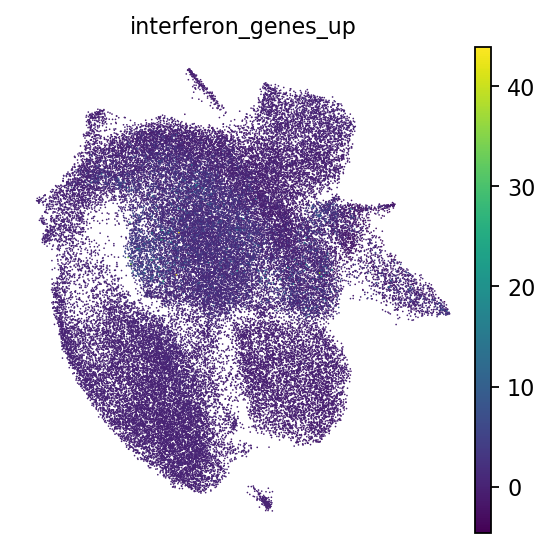

In [19]:
sc.pl.umap(adata, color=['interferon_genes_up'])

## 4. Z-scaled gene signature heatmap

This clustered heatmap shows mean gene set scores across different plasma cell subtypes, with **column-wise z-score normalization** applied.

### Key Points:
- The heatmap displays gene set activity patterns (rows) across plasma states (columns)
- Hierarchical clustering reveals which states share similar transcriptional profiles and which gene sets co-vary together

### Z-Score Scaling Impact:

With `z_score=0`, each **gene set** is independently standardized:

**What this means:**
- For each gene set row, the z-score is calculated using that gene set's mean and standard deviation **across all states**
- **Red (positive z-score)**: This cell type has **higher than average** activity for this specific gene set compared to other states
- **Blue (negative z-score)**: This cell type has **lower than average** activity for this specific gene set compared to other states
- **White/neutral**: Near the average activity level for that gene set

**Why this matters:**
- Standardization removes the influence of different baseline expression levels between gene sets, putting them on a comparable scale
- Highlights **cell type-specific enrichments** rather than absolute expression magnitudes
- Allows identification of defining signatures for each plasma cell subtype by revealing which gene sets are selectively up- or down-regulated in specific populations

In [20]:
signature_to_author_label = {
    'W1_unknown': 'Boiarsky | Unknown W1',
    'W2_MM1': 'Boiarsky | MM1 State',
    'W3_t11_14': 'Boiarsky | t(11;14)',
    'W4_HLA_class_II': 'Boiarsky | HLA Class II',
    'W5_histones': 'Boiarsky | Histone',
    'W6_unknown': 'Boiarsky | Unknown W6',
    'W7_MM4': 'Boiarsky | MM4 State',
    'W8_t14_20': 'Boiarsky | t(14;20)',
    'W9_extracellular_signaling': 'Boiarsky | Extracellular Signal',
    'W10_RPL36A': 'Boiarsky | RPL36A',
    'W11_proliferation': 'Boiarsky | Proliferation',
    'W12_monocytic_contamination': 'Boiarsky | Monocyte',
    'W13_FOS': 'Boiarsky | FOS/AP-1',
    'W14_unknown': 'Boiarsky | Unknown W14',
    'W15_SMM8': 'Boiarsky | SMM8 State',
    'W16_normal_plasma': 'Boiarsky | Normal Plasma',
    'W17_MM5': 'Boiarsky | MM5 State (MYC)',
    'W18_JUN': 'Boiarsky | JUN',
    'W19_SMM7': 'Boiarsky | SMM7 State',
    'W20_protein_synthesis': 'Boiarsky | Protein synthesis',
    'W21_HSPA5': 'Boiarsky | HSPA5',
    'W22_TMSB4X': 'Boiarsky | TMSB4X',
    'W23_MM3': 'Boiarsky | MM3 State',
    'W24_interferon_inducible': 'Boiarsky | ISG',
    'W25_UBC': 'Boiarsky | Ubiquitin C Up',
    'W26_unknown': 'Boiarsky | Unknown W26',
    'W27_nuclear_genes_opposite': 'Boiarsky | Nuclear Regulation',
    'W28_CXCR4': 'Boiarsky | CXCR4',
    'CTA_up': 'Broyl | Testis Ag',
    'CD2_up': 'Broyl | CCND1 - B cell high',
    'CD1_up': 'Broyl | CCND1 - B cell low',
    'HY_up': 'Broyl | Hyperdiploid',
    'MF_up': 'Broyl | MAF/MAFB',
    'MS_up': 'Broyl | MMSET/FGFR3',
    'M_up': 'Broyl | Monocyte/Neutrophil',
    'NF_up': 'Broyl | NFκB',
    'PR_up': 'Broyl | Proliferation',
    'PRL3_up': 'Broyl | PTP4A3/STAT3',
    'APOBEC_score_mean': 'Internal | APOBEC Activity',
    'interferon_genes_up': 'Internal | ISG',
    'Interferon_Alpha_Response': 'MSigDB | ISG Alpha',
    'Interferon_Gamma_Response': 'MSigDB | ISG Gamma',
}

In [21]:
score_cols = list(signature_to_author_label.keys())

/tmp/ipykernel_22840/1769461076.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  heatmap_data = df_scores.groupby("plasma_labels_l3")[score_cols].mean()


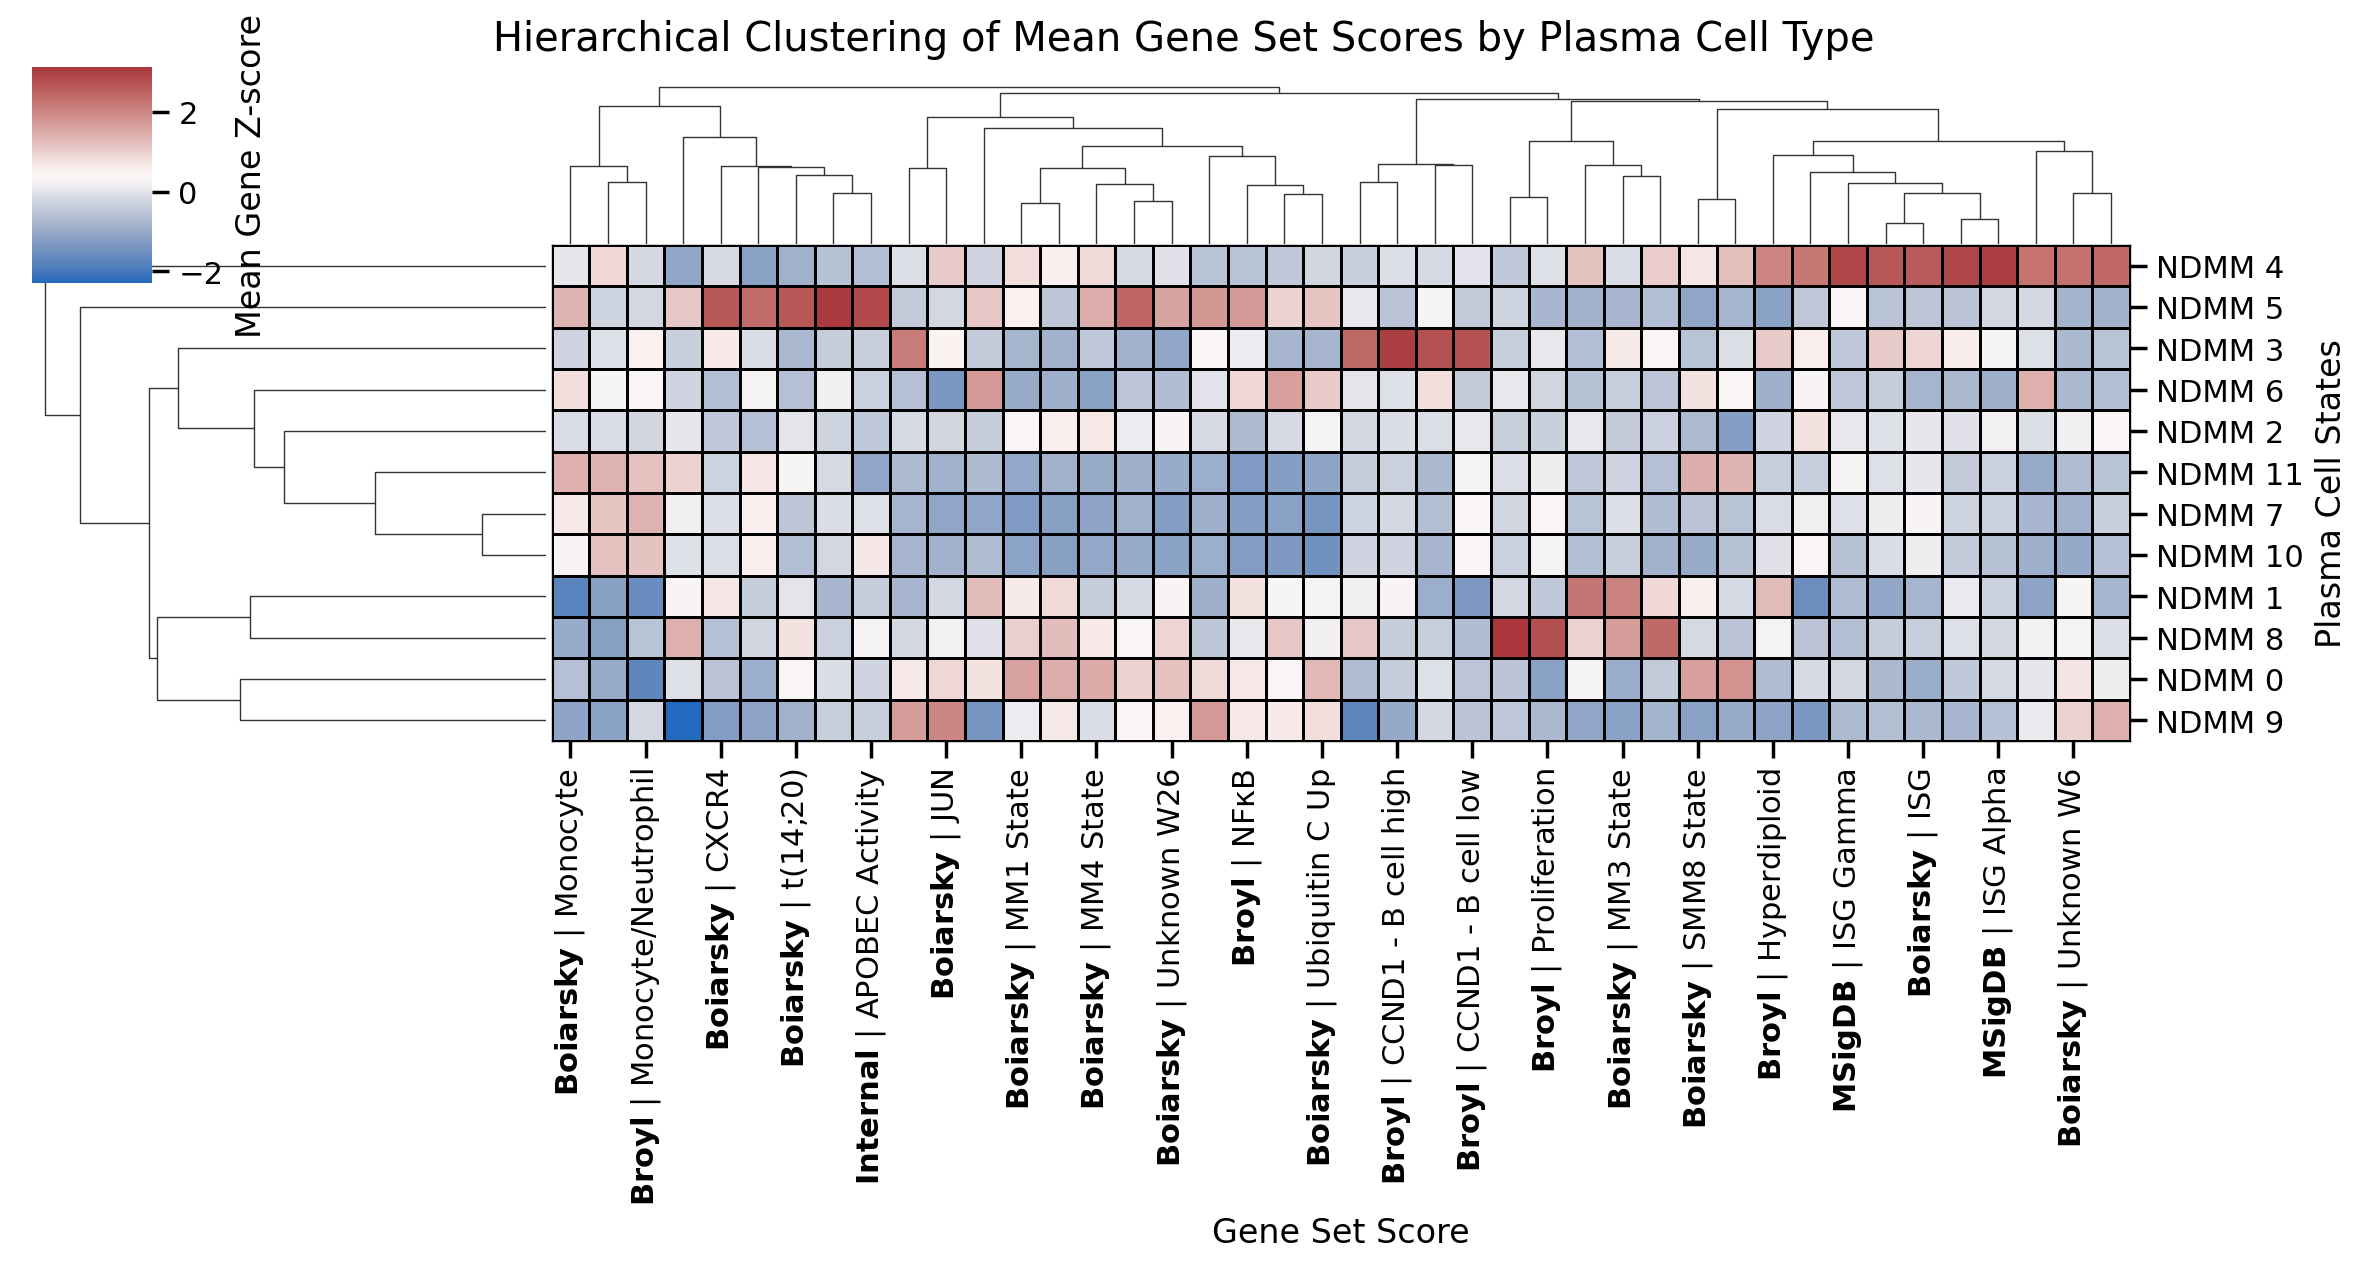

In [22]:
plt.style.use("default")
sns.set_context("notebook", font_scale=1)

df_scores = adata.obs[["plasma_labels_l3"] + score_cols]
heatmap_data = df_scores.groupby("plasma_labels_l3")[score_cols].mean()
heatmap_data.rename(columns=signature_to_author_label, inplace=True)

# Create bold formatting for column names
def format_column_name(col_name):
    if "|" in col_name:
        author, gene_set = col_name.split("|", 1)
        return f"$\\bf{{{author.strip()}}}$ | {gene_set.strip()}"
    return col_name

# Apply bold formatting to column names
heatmap_data.columns = [format_column_name(col) for col in heatmap_data.columns]

clustermap = sns.clustermap(
    heatmap_data,
    z_score=1,  # Change to 1 for column-wise z-score (gene sets)
    cmap="vlag",
    figsize=(12, 6),
    linewidths=0.4,
    dendrogram_ratio=0.25,
    linecolor="black",
    cbar_kws={"label": "Mean Gene Z-score"},
)
clustermap.ax_heatmap.set_ylabel("Plasma Cell States")
clustermap.ax_heatmap.set_xlabel("Gene Set Score")

# Add black border around the heatmap
for spine in clustermap.ax_heatmap.spines.values():
    spine.set_visible(True)
    spine.set_linewidth(0.5)
    spine.set_edgecolor("black")

plt.suptitle(
    "Hierarchical Clustering of Mean Gene Set Scores by Plasma Cell Type", y=1.02
)
plt.show()

In [28]:
heatmap_data.to_csv('../../../data/rna/plasma-subsets/plasma_lit-state_scores_summary.csv')

## 5. Export data for figures

In [23]:
adata.write('../../../data/rna/plasma-subsets/plasma_state_scores.h5ad')

export_cols = ['plasma_labels_l3'] + score_cols
adata.obs[export_cols].to_csv('../../../data/rna/plasma-subsets/plasma_state_single_cell_scores.csv')